In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv') 
### based on checks characteristics of the data, we will convert TotalCharges to numeric type for analysis
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')  # Convert to numeric, coerce errors to NaN
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

On changing the data type from **str** to **float64** for `TotalCharges` we get some 11 NULL values.

In [4]:
null_rows = df[df['TotalCharges'].isna()]
print(len(null_rows))

11


## Univariate Analysis

#### customerID

In [5]:

df['customerID'].nunique() # 7043 unique values

7043

#### gender

In [6]:
np.round(100*df['gender'].value_counts(normalize=True),2)
# 50.4% Male, 49.6% Female

gender
Male      50.48
Female    49.52
Name: proportion, dtype: float64

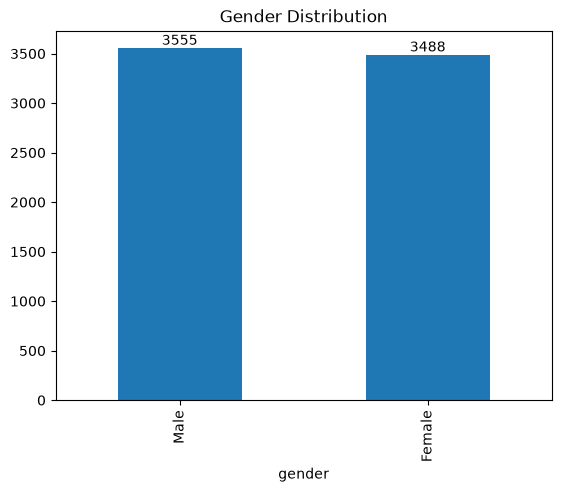

In [7]:
ax = df['gender'].value_counts().plot(kind='bar', title='Gender Distribution')
ax.bar_label(ax.containers[0], label_type='edge')
plt.show();

In [8]:
### function to check for the bar graph and number and % of vaulues in a column
def univariate_check_column(df, column):
    ax = df[column].value_counts().plot(kind='bar', title=f'{column} Distribution')
    ax.bar_label(ax.containers[0], label_type='edge')
    plt.show();

    print(f"Percentage of unique values in {column}: ")
    print(np.round(100*df[column].value_counts(normalize=True),2))

#### SeniorCitizen
Only 16% of the population is senior citizen.

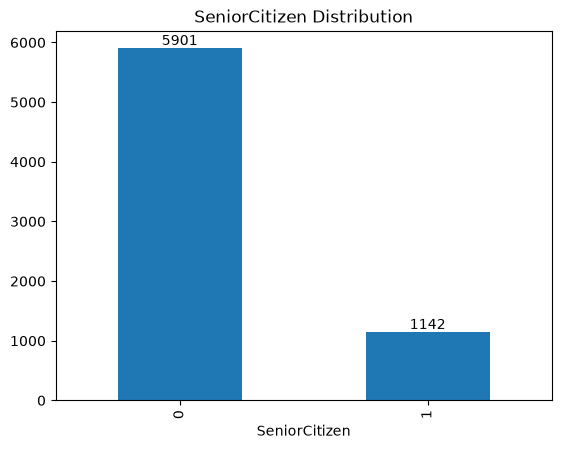

Percentage of unique values in SeniorCitizen: 
SeniorCitizen
0    83.79
1    16.21
Name: proportion, dtype: float64


In [9]:
univariate_check_column(df,'SeniorCitizen')

#### Partner
52% of customers have partners and 48% don't.

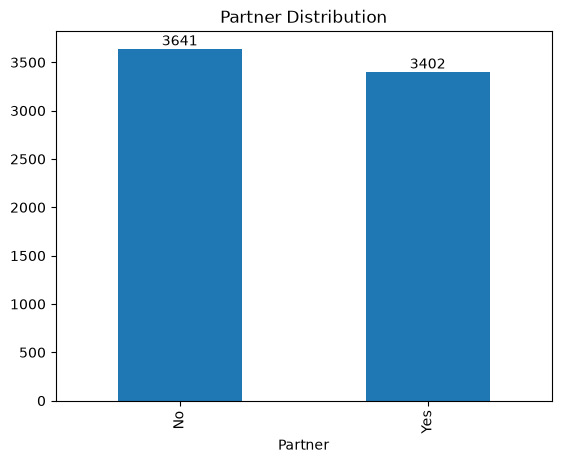

Percentage of unique values in Partner: 
Partner
No     51.7
Yes    48.3
Name: proportion, dtype: float64


In [10]:
univariate_check_column(df,'Partner')

#### Dependents

30% of the customers have dependents.

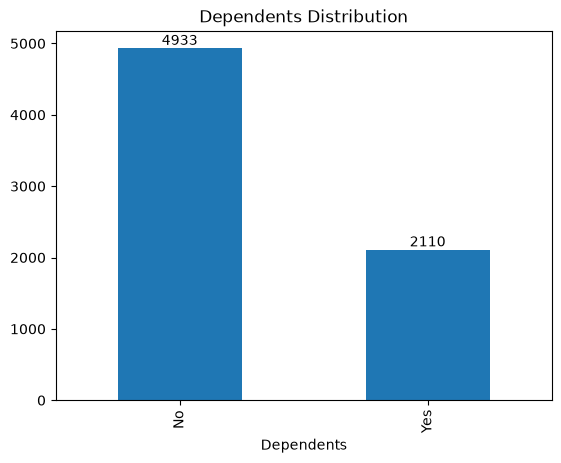

Percentage of unique values in Dependents: 
Dependents
No     70.04
Yes    29.96
Name: proportion, dtype: float64


In [11]:
univariate_check_column(df,'Dependents')

#### tenure

**Definition**: Number of months the customer has stayed with the company

As its not a categorical data, we have to check the numerical distribution.

In [12]:
df['tenure'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

<Axes: title={'center': 'Tenure Distribution'}, ylabel='Frequency'>

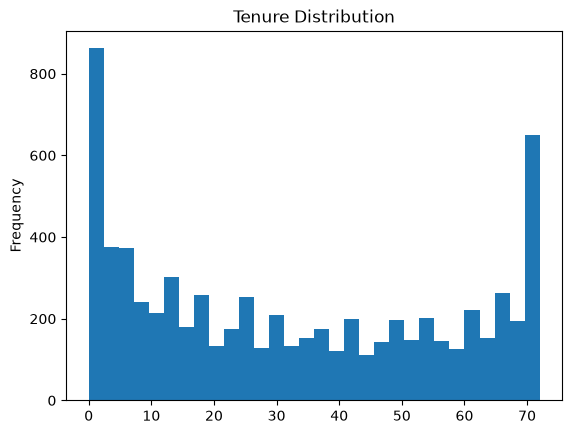

In [13]:
df['tenure'].plot(kind='hist', bins=30, title='Tenure Distribution')

- tenure histogram is **U-shaped**: tall spikes at both ends and a fairly flat middle. It shows how long the current customer base has been with the company.

- The spike at 72 is a cap, not real behaviour. The data stops at 72 months (6 years), so anyone who has been a customer longer is recorded as 72. The spike is a pile-up at the ceiling.

#### PhoneService
**Definition:** Whether the customer has a phone service or not (Yes, No)

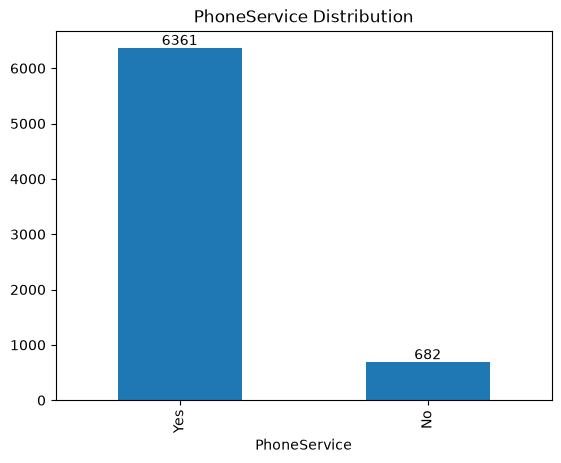

Percentage of unique values in PhoneService: 
PhoneService
Yes    90.32
No      9.68
Name: proportion, dtype: float64


In [14]:
univariate_check_column(df,'PhoneService')

#### MultipleLines

**Definition:** Whether the customer has multiple lines or not (Yes, No, No phone service)

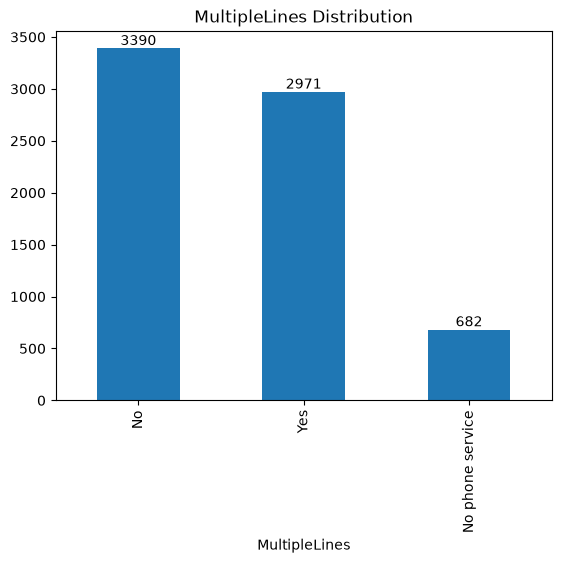

Percentage of unique values in MultipleLines: 
MultipleLines
No                  48.13
Yes                 42.18
No phone service     9.68
Name: proportion, dtype: float64


In [15]:
univariate_check_column(df,'MultipleLines')

The `MultipleLines` column checks if the customers who have an existing Phone Service how many of them have multiple or no `PhoneService`.

<Axes: xlabel='PhoneService', ylabel='Count'>

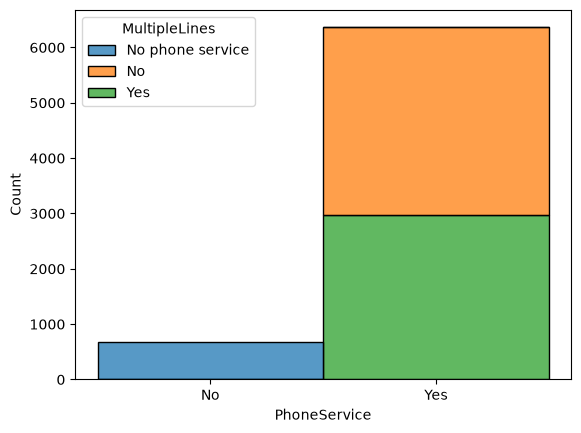

In [16]:
sns.histplot(df, x='PhoneService', hue='MultipleLines', bins=36, multiple='stack')

#### InternetService
**Definition**: Customer’s internet service provider (DSL, Fiber optic, No)

**DSL stands for Digital Subscriber Line.** It's home internet that runs over ordinary copper telephone lines. It's older and slower than fibre, and speeds drop the further you are from the exchange. 

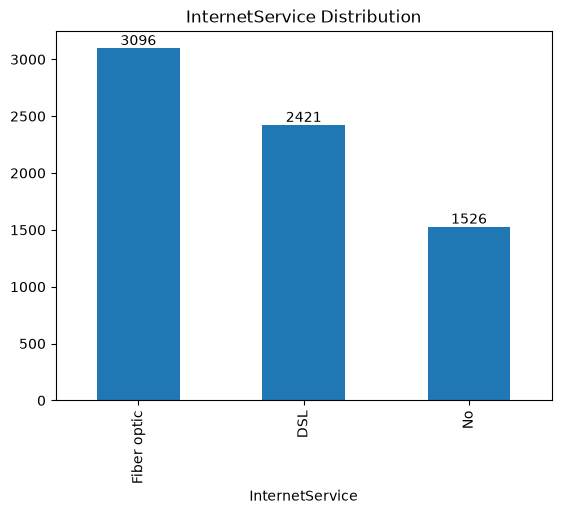

Percentage of unique values in InternetService: 
InternetService
Fiber optic    43.96
DSL            34.37
No             21.67
Name: proportion, dtype: float64


In [17]:
univariate_check_column(df,'InternetService')

#### OnlineSecurity
**Definition:** Whether the customer has online security or not (Yes, No, No internet service)

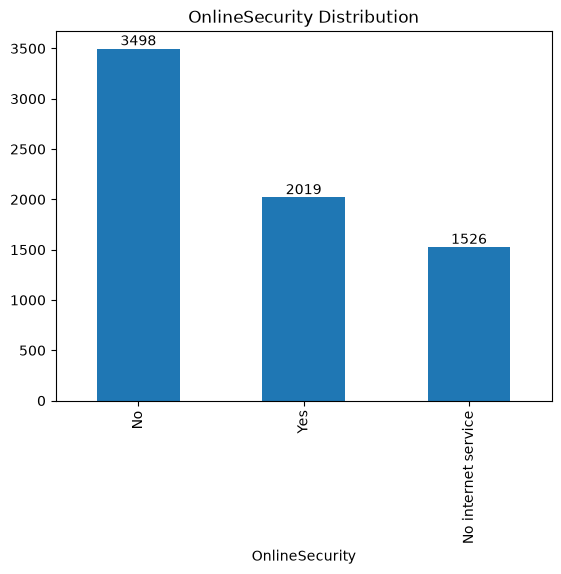

Percentage of unique values in OnlineSecurity: 
OnlineSecurity
No                     49.67
Yes                    28.67
No internet service    21.67
Name: proportion, dtype: float64


In [18]:
univariate_check_column(df,'OnlineSecurity')

#### OnlineBackup

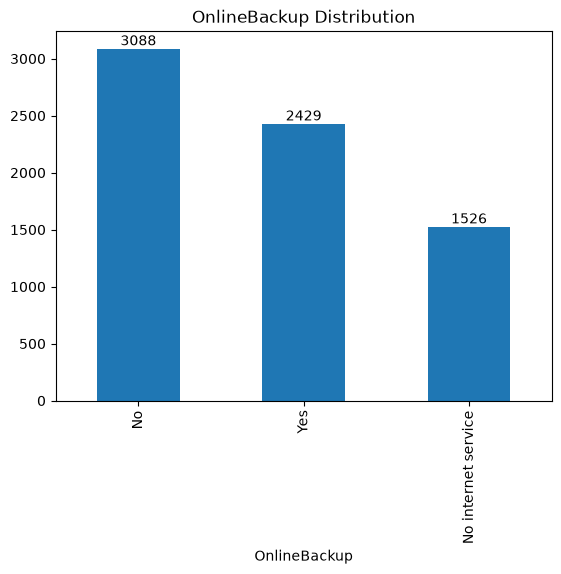

Percentage of unique values in OnlineBackup: 
OnlineBackup
No                     43.84
Yes                    34.49
No internet service    21.67
Name: proportion, dtype: float64


In [19]:
univariate_check_column(df,'OnlineBackup')

#### DeviceProtection

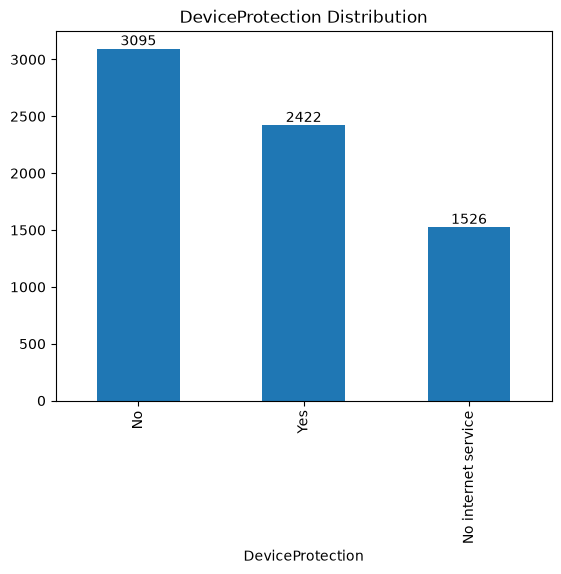

Percentage of unique values in DeviceProtection: 
DeviceProtection
No                     43.94
Yes                    34.39
No internet service    21.67
Name: proportion, dtype: float64


In [20]:
univariate_check_column(df,'DeviceProtection')

#### TechSupport

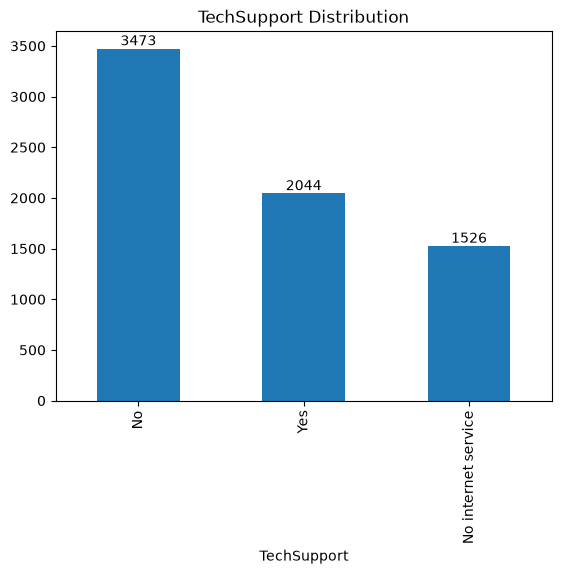

Percentage of unique values in TechSupport: 
TechSupport
No                     49.31
Yes                    29.02
No internet service    21.67
Name: proportion, dtype: float64


In [21]:
univariate_check_column(df,'TechSupport')

#### StreamingTV

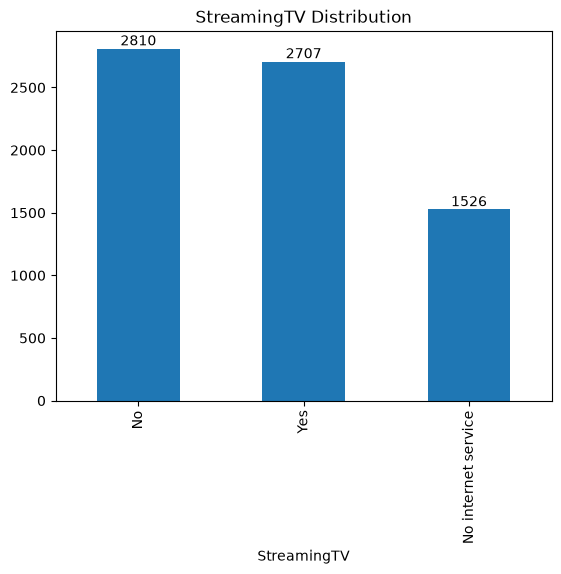

Percentage of unique values in StreamingTV: 
StreamingTV
No                     39.90
Yes                    38.44
No internet service    21.67
Name: proportion, dtype: float64


In [22]:
univariate_check_column(df,'StreamingTV')

#### StreamingMovies

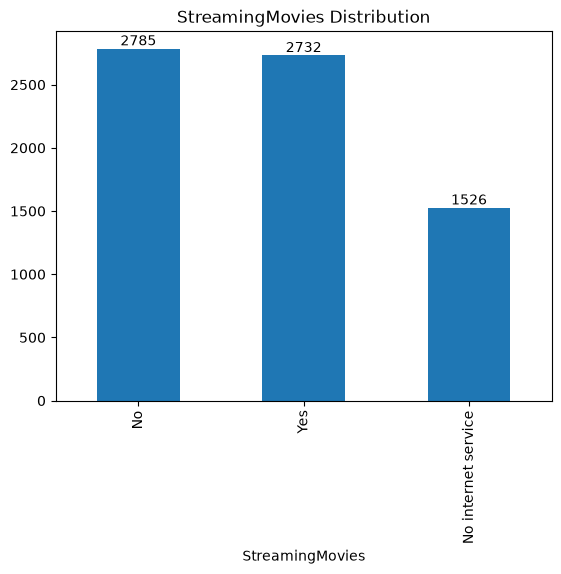

Percentage of unique values in StreamingMovies: 
StreamingMovies
No                     39.54
Yes                    38.79
No internet service    21.67
Name: proportion, dtype: float64


In [23]:
univariate_check_column(df,'StreamingMovies')

#### Contract

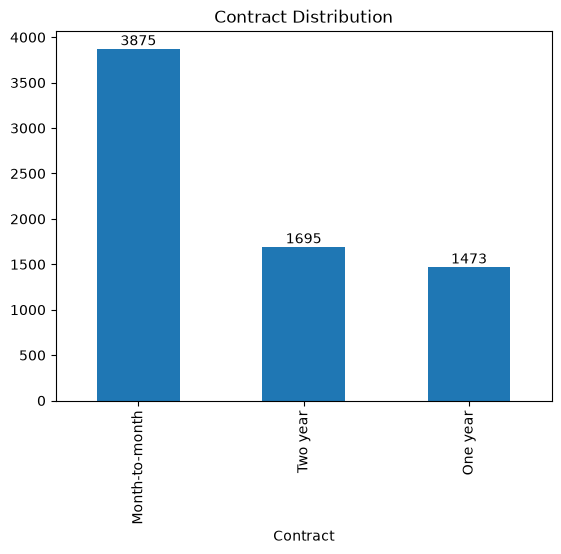

Percentage of unique values in Contract: 
Contract
Month-to-month    55.02
Two year          24.07
One year          20.91
Name: proportion, dtype: float64


In [24]:
univariate_check_column(df,'Contract')

#### PaperlessBilling

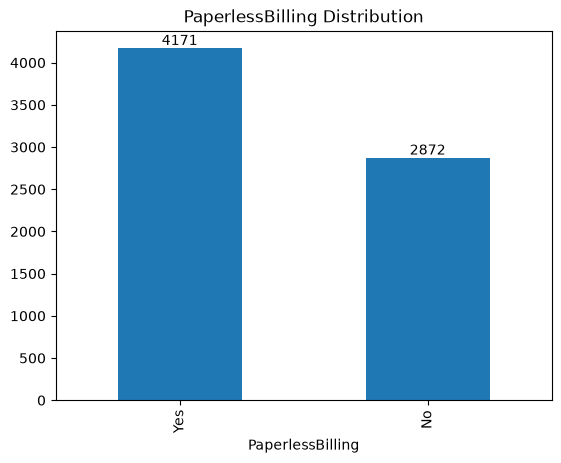

Percentage of unique values in PaperlessBilling: 
PaperlessBilling
Yes    59.22
No     40.78
Name: proportion, dtype: float64


In [25]:
univariate_check_column(df,'PaperlessBilling')

#### PaymentMethod

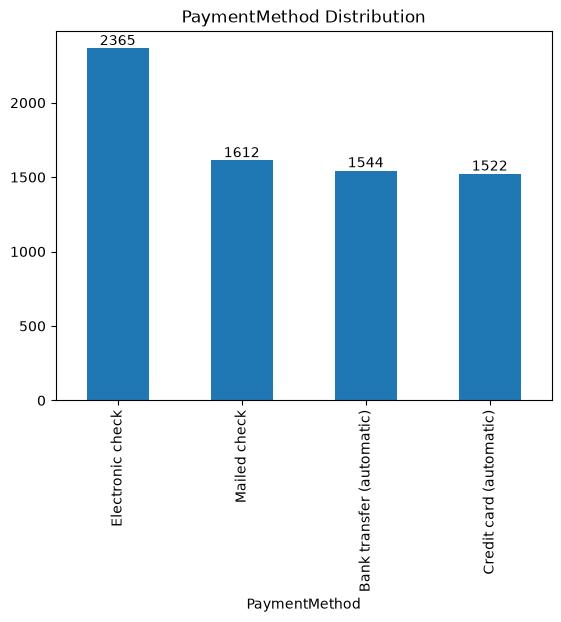

Percentage of unique values in PaymentMethod: 
PaymentMethod
Electronic check             33.58
Mailed check                 22.89
Bank transfer (automatic)    21.92
Credit card (automatic)      21.61
Name: proportion, dtype: float64


In [26]:
univariate_check_column(df,'PaymentMethod')

#### MonthlyCharges

In [27]:
df['MonthlyCharges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

<Axes: title={'center': 'Monthly Charges Distribution'}, ylabel='Frequency'>

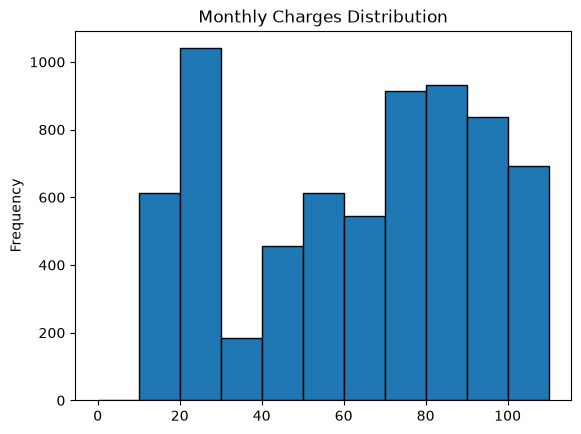

In [28]:
df['MonthlyCharges'].plot(kind='hist', bins = np.arange(0,120,10), 
                          title='Monthly Charges Distribution',
                           edgecolor='black')

#### TotalCharges

This column has data type - str but should have been float.  
Made this change - converted from str to float64. 



In [29]:
df['TotalCharges'].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

<Axes: title={'center': 'Total Charges Distribution'}, ylabel='Frequency'>

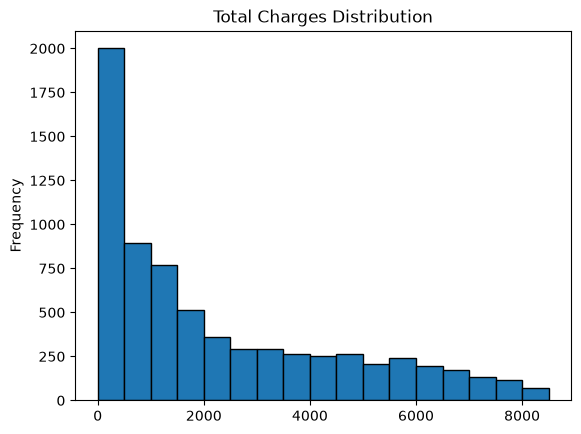

In [30]:
df['TotalCharges'].plot(kind='hist', bins = np.arange(0,9000,500), 
                          title='Total Charges Distribution',
                           edgecolor='black')

The dataset is right skewed. majority of the customers have have paid less than $500. 

`TotalCharges` is roughly `tenure` x `MonthlyCharges`.  Churners will have lower `TotalCharges`.

As `TotalCharges` is dependant on `tenure` and `MonthlyCharges` blindly assigning mode/median or any value will not be correct so need to check the data of those rows which have `TotalCharges` as null.

In [35]:
df.loc[df['TotalCharges'].isna(),:]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


None of these 11 customers have churned.  
Their tenure is 0 and all of them have monthly charges value.  None of them are SeniorCitizens. And all of them have dependants and  9 of them have partners.  
10 out of the 11 customers have 2 year contract and 1 customer has 1 year contract.


As the Tenure of the customer is zero this means that these are new customers and have not been billed yet. So will be filling the null with 0 values.

In [37]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [38]:
df['TotalCharges'].isnull().sum()

np.int64(0)

#### Churn

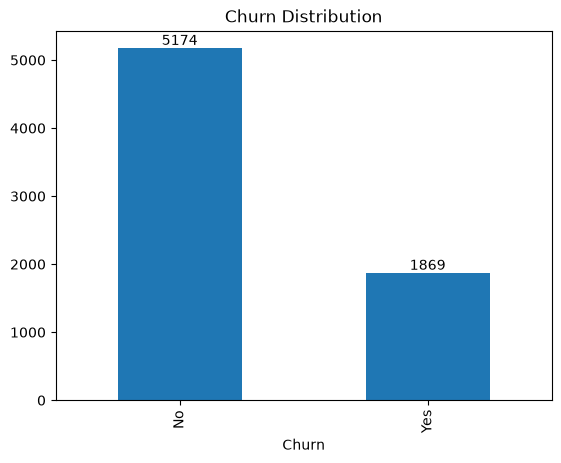

Percentage of unique values in Churn: 
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [39]:
univariate_check_column(df,'Churn')

So our dataset is imbalanced as 73% of the customers have not churned and 27% have churned.

Cleaned data is moved to the interim folder.

In [42]:
df.to_excel("../data/interim/telco_customer_churn_interim.xlsx", index=False)

<Axes: xlabel='tenure', ylabel='Count'>

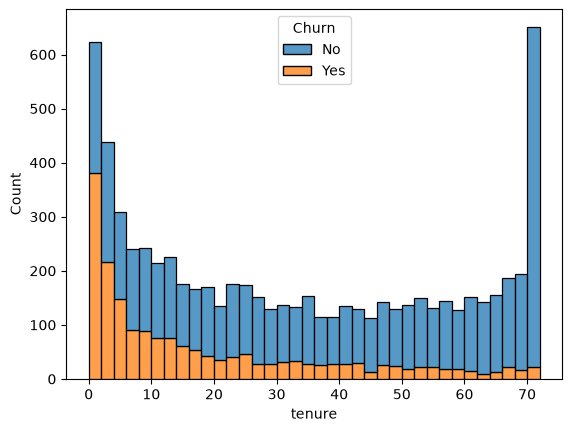

In [ ]:
# sns.histplot(df, x='tenure', hue='Churn', bins=36, multiple='stack')